In [24]:
import pandas as pd
from sklearn.model_selection import train_test_split

In [2]:
file_path1 = r'C:\Users\NishthaNarayan\Downloads\secom\secom.data'
file_path2 = r'C:\Users\NishthaNarayan\Downloads\secom\secom_labels.data'
file_path3 = r'C:\Users\NishthaNarayan\Downloads\secom\secom.names' # this is only an info file

column_names = [f'feature{i}' for i in range(1, 591)]

# Read the .data file using pandas
data1 = pd.read_csv(file_path1, delimiter=' ', names = column_names)
data1

,feature1,feature2,feature3,feature4,feature5,feature6,feature7,feature8,feature9,feature10,...,feature581,feature582,feature583,feature584,feature585,feature586,feature587,feature588,feature589,feature590
0,3030.93,2564.00,2187.7333,1411.1265,1.3602,100.0,97.6133,0.1242,1.5005,0.0162,...,NaN,NaN,0.5005,0.0118,0.0035,2.3630,NaN,NaN,NaN,NaN
1,3095.78,2465.14,2230.4222,1463.6606,0.8294,100.0,102.3433,0.1247,1.4966,-0.0005,...,0.0060,208.2045,0.5019,0.0223,0.0055,4.4447,0.0096,0.0201,0.0060,208.2045
2,2932.61,2559.94,2186.4111,1698.0172,1.5102,100.0,95.4878,0.1241,1.4436,0.0041,...,0.0148,82.8602,0.4958,0.0157,0.0039,3.1745,0.0584,0.0484,0.0148,82.8602
3,2988.72,2479.90,2199.0333,909.7926,1.3204,100.0,104.2367,0.1217,1.4882,-0.0124,...,0.0044,73.8432,0.4990,0.0103,0.0025,2.0544,0.0202,0.0149,0.0044,73.8432
4,3032.24,2502.87,2233.3667,1326.5200,1.5334,100.0,100.3967,0.1235,1.5031,-0.0031,...,NaN,NaN,0.4800,0.4766,0.1045,99.3032,0.0202,0.0149,0.0044,73.8432
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1562,2899.41,2464.36,2179.7333,3085.3781,1.4843,100.0,82.2467,0.1248,1.3424,-0.0045,...,0.0047,203.1720,0.4988,0.0143,0.0039,2.8669,0.0068,0.0138,0.0047,203.1720
1563,3052.31,2522.55,2198.5667,1124.6595,0.8763,100.0,98.4689,0.1205,1.4333,-0.0061,...,NaN,NaN,0.4975,0.0131,0.0036,2.6238,0.0068,0.0138,0.0047,203.1720
1564,2978.81,2379.78,2206.3000,1110.4967,0.8236,100.0,99.4122,0.1208,NaN,NaN,...,0.0025,43.5231,0.4987,0.0153,0.0041,3.0590,0.0197,0.0086,0.0025,43.5231
1565,2894.92,2532.01,2177.0333,1183.7287,1.5726,100.0,98.7978,0.1213,1.4622,-0.0072,...,0.0075,93.4941,0.5004,0.0178,0.0038,3.5662,0.0262,0.0245,0.0075,93.4941


In [3]:
data2 = pd.read_csv(file_path2, delimiter=' ', names = ['LABEL','TIMESTAMP'])
data2

,LABEL,TIMESTAMP
0,-1,19/07/2008 11:55:00
1,-1,19/07/2008 12:32:00
2,1,19/07/2008 13:17:00
3,-1,19/07/2008 14:43:00
4,-1,19/07/2008 15:22:00
...,...,...
1562,-1,16/10/2008 15:13:00
1563,-1,16/10/2008 20:49:00
1564,-1,17/10/2008 05:26:00
1565,-1,17/10/2008 06:01:00


In [4]:
data2['LABEL'].unique #1 or -1 -1 is pass 

<bound method Series.unique of 0      -1
1      -1
2       1
3      -1
4      -1
       ..
1562   -1
1563   -1
1564   -1
1565   -1
1566   -1
Name: LABEL, Length: 1567, dtype: int64>

In [12]:
with open(r'C:\Users\NishthaNarayan\Downloads\secom\secom.names', 'r') as file:
    names_content = file.read()

# Print the content
print(names_content)

Title: SECOM Data Set

Abstract: Data from a semi-conductor manufacturing process
	

-----------------------------------------------------

Data Set Characteristics: Multivariate
Number of Instances: 1567
Area: Computer
Attribute Characteristics: Real
Number of Attributes: 591
Date Donated: 2008-11-19
Associated Tasks: Classification, Causal-Discovery
Missing Values? Yes

-----------------------------------------------------

Source:

Authors: Michael McCann, Adrian Johnston 

-----------------------------------------------------

Data Set Information:

A complex modern semi-conductor manufacturing process is normally under consistent 
surveillance via the monitoring of signals/variables collected from sensors and or 
process measurement points. However, not all of these signals are equally valuable 
in a specific monitoring system. The measured signals contain a combination of 
useful information, irrelevant information as well as noise. It is often the case 
that useful information i

In [5]:
max_values = data1.max()
min_values = data1.min()

# Create a DataFrame to store the max and min values
max_min_df = pd.DataFrame({'Column': data1.columns,
                           'Max_Value': max_values.values,
                           'Min_Value': min_values.values})

# Display the DataFrame
max_min_df

,Column,Max_Value,Min_Value
0,feature1,3356.3500,2743.2400
1,feature2,2846.4400,2158.7500
2,feature3,2315.2667,2060.6600
3,feature4,3715.0417,0.0000
4,feature5,1114.5366,0.6815
...,...,...,...
585,feature586,99.3032,1.1975
586,feature587,0.1028,-0.0169
587,feature588,0.0799,0.0032
588,feature589,0.0286,0.0010


In [6]:
value = max_min_df['Max_Value'].max()
value

37943.0

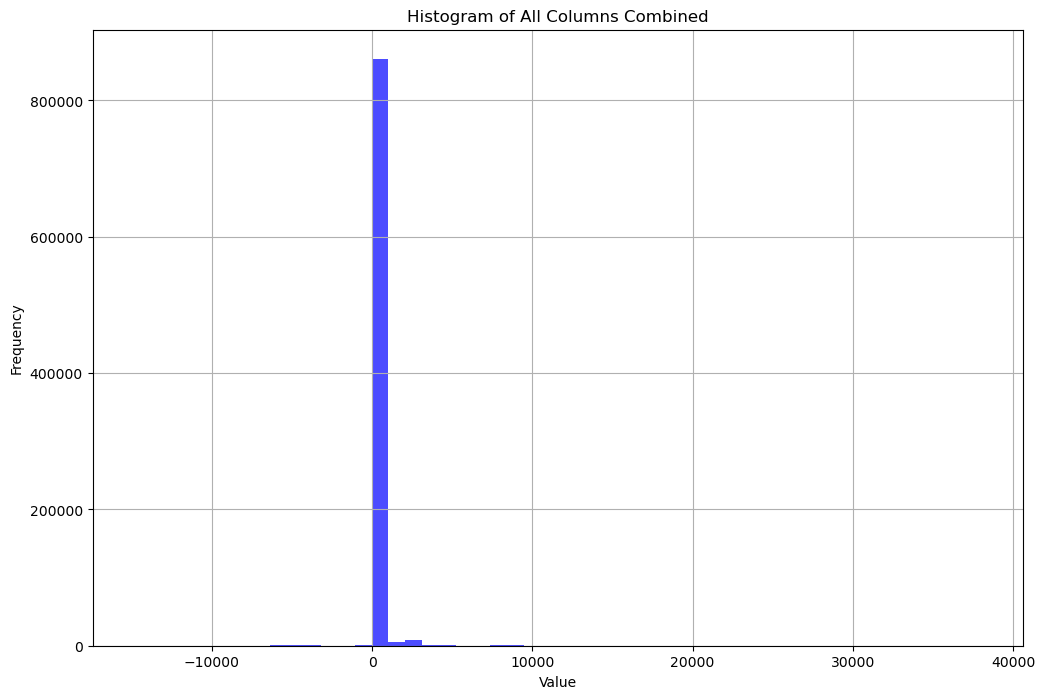

In [24]:
import matplotlib.pyplot as plt
all_columns_series = data1.values.flatten()
# Create a histogram for the concatenated series
plt.figure(figsize=(12, 8))
plt.hist(all_columns_series, bins=50, color='blue', alpha=0.7)
plt.title('Histogram of All Columns Combined')
plt.xlabel('Value')
plt.ylabel('Frequency')
plt.grid(True)
plt.show()

In [34]:
freq_data = []

# Iterate over each column in the original DataFrame
for col in data1.columns:
    # Count the frequency of NaN values in the column
    nan_freq = data1[col].isna().sum()
    # Count the frequency of non-NaN values in the column
    non_nan_freq = data1[col].notna().sum()
    # Append the information to the frequency list
    freq_data.append({'Column_Name': col,
                      'MissingVal count': nan_freq,
                      'non-missingVal count': non_nan_freq})

# Create a DataFrame from the list of dictionaries
freq_df = pd.DataFrame(freq_data)
freq_df['Percentage of missing values'] = freq_df['MissingVal count']/(freq_df['non-missingVal count']+freq_df['MissingVal count'])
freq_df

,Column_Name,MissingVal count,non-missingVal count,Percentage of missing values
0,feature1,6,1561,0.003829
1,feature2,7,1560,0.004467
2,feature3,14,1553,0.008934
3,feature4,14,1553,0.008934
4,feature5,14,1553,0.008934
...,...,...,...,...
585,feature586,1,1566,0.000638
586,feature587,1,1566,0.000638
587,feature588,1,1566,0.000638
588,feature589,1,1566,0.000638


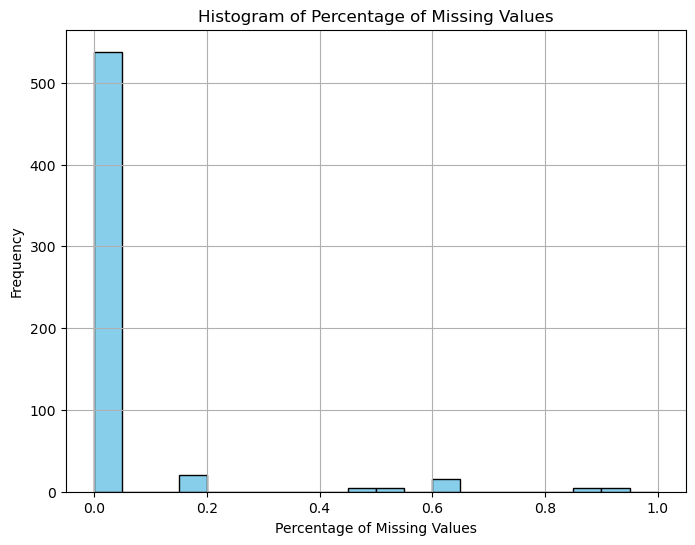

In [35]:
plt.figure(figsize=(8, 6))
plt.hist(freq_df['Percentage of missing values'], bins=20, range=(0, 1), color='skyblue', edgecolor='black')
plt.title('Histogram of Percentage of Missing Values')
plt.xlabel('Percentage of Missing Values')
plt.ylabel('Frequency')
plt.grid(True)
plt.show()

In [36]:
val = freq_df['Percentage of missing values'].max()
val

0.9119336311423102

In [42]:
file_path = r"C:\Users\NishthaNarayan\Downloads\SECOM sem2\data_file.csv"  # Replace "path/to/your/file.csv" with the desired file path

# Export the DataFrame to a CSV file
data1.to_csv(file_path, index=False, sep= '|')

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
 
# Assuming you have a DataFrame named 'df' with 590 columns
 
# Compute the correlation matrix
correlation_matrix = data.corr()
 
# Set up the matplotlib figure
plt.figure(figsize=(20, 15))  # Adjust figure size as needed
 
# Create a heatmap with the correlation matrix
sns.heatmap(correlation_matrix, cmap='coolwarm', annot=False)  # Set annot=True for numerical annotations
 
# Add title
plt.title('Correlation Heatmap of 590 Columns')
 
# Show plot
plt.show()

In [ ]:
#-1 corresponds to pass and 1 to fail   
 
# Assuming you have a DataFrame named 'df' with a column named 'column_name'
 
# Count occurrences of values in the 'column_name' column
value_counts = labels['Pass&Fail'].value_counts()
 
# Display the counts
print(value_counts)

In [44]:
file_path = r"C:\Users\NishthaNarayan\Downloads\SECOM sem2\OutlierCounts.csv"  # Replace "path/to/your/file.csv" with the desired file path

# Export the DataFrame to a CSV file
oulier_df.to_csv(file_path, index=False, sep= ',')

LABEL        30
TIMESTAMP    30
dtype: int64

In [7]:
#Merge data
data = pd.concat([data1, data2], axis=1)
data

,feature1,feature2,feature3,feature4,feature5,feature6,feature7,feature8,feature9,feature10,...,feature583,feature584,feature585,feature586,feature587,feature588,feature589,feature590,LABEL,TIMESTAMP
0,3030.93,2564.00,2187.7333,1411.1265,1.3602,100.0,97.6133,0.1242,1.5005,0.0162,...,0.5005,0.0118,0.0035,2.3630,NaN,NaN,NaN,NaN,-1,19/07/2008 11:55:00
1,3095.78,2465.14,2230.4222,1463.6606,0.8294,100.0,102.3433,0.1247,1.4966,-0.0005,...,0.5019,0.0223,0.0055,4.4447,0.0096,0.0201,0.0060,208.2045,-1,19/07/2008 12:32:00
2,2932.61,2559.94,2186.4111,1698.0172,1.5102,100.0,95.4878,0.1241,1.4436,0.0041,...,0.4958,0.0157,0.0039,3.1745,0.0584,0.0484,0.0148,82.8602,1,19/07/2008 13:17:00
3,2988.72,2479.90,2199.0333,909.7926,1.3204,100.0,104.2367,0.1217,1.4882,-0.0124,...,0.4990,0.0103,0.0025,2.0544,0.0202,0.0149,0.0044,73.8432,-1,19/07/2008 14:43:00
4,3032.24,2502.87,2233.3667,1326.5200,1.5334,100.0,100.3967,0.1235,1.5031,-0.0031,...,0.4800,0.4766,0.1045,99.3032,0.0202,0.0149,0.0044,73.8432,-1,19/07/2008 15:22:00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1562,2899.41,2464.36,2179.7333,3085.3781,1.4843,100.0,82.2467,0.1248,1.3424,-0.0045,...,0.4988,0.0143,0.0039,2.8669,0.0068,0.0138,0.0047,203.1720,-1,16/10/2008 15:13:00
1563,3052.31,2522.55,2198.5667,1124.6595,0.8763,100.0,98.4689,0.1205,1.4333,-0.0061,...,0.4975,0.0131,0.0036,2.6238,0.0068,0.0138,0.0047,203.1720,-1,16/10/2008 20:49:00
1564,2978.81,2379.78,2206.3000,1110.4967,0.8236,100.0,99.4122,0.1208,NaN,NaN,...,0.4987,0.0153,0.0041,3.0590,0.0197,0.0086,0.0025,43.5231,-1,17/10/2008 05:26:00
1565,2894.92,2532.01,2177.0333,1183.7287,1.5726,100.0,98.7978,0.1213,1.4622,-0.0072,...,0.5004,0.0178,0.0038,3.5662,0.0262,0.0245,0.0075,93.4941,-1,17/10/2008 06:01:00


In [47]:
#Duplicates
duplicate_rows = data[data.duplicated()]


# If you want to create a new DataFrame containing only the duplicate records:
#duplicate_rows = data1[data1.duplicated(keep=False)]
duplicate_rows

,feature1,feature2,feature3,feature4,feature5,feature6,feature7,feature8,feature9,feature10,...,feature583,feature584,feature585,feature586,feature587,feature588,feature589,feature590,LABEL,TIMESTAMP


## Measures of Central tendency

In [16]:
import pandas as pd

# Function to calculate mode
def calculate_mode(column):
    try:
        mode = column.mode()[0]
    except:
        mode = None
    return mode

# Function to calculate mean, median, and mode for each column
def calculate_stats(column):
    mean = column.mean()
    median = column.median()
    mode = calculate_mode(column)
    variance = column.var()
    return pd.Series({'mean': mean, 'median': median, 'mode': mode, 'variance': variance})


# Create a list to store the results
results = []

# Iterate through each column in the original DataFrame
for col_name in data1.columns:
    # Sort the column and calculate statistics
    sorted_col = data1[col_name].sort_values()
    stats = calculate_stats(sorted_col)

    
    # Append the results to the list
    results.append({'column name': col_name, 
                    'mean': stats['mean'], 
                    'median': stats['median'], 
                    'mode': stats['mode'],
                   'Variance': stats['variance']})

# Create a DataFrame from the results list
result_df = pd.DataFrame(results)

# Calculate variance for each column

result_df

,column name,mean,median,mode,Variance
0,feature1,3014.452896,3011.49000,2908.1100,5420.167484
1,feature2,2495.850231,2499.40500,2499.7200,6465.399020
2,feature3,2200.547318,2201.06670,2171.8556,871.026144
3,feature4,1396.376627,1285.21440,940.9917,195091.505178
4,feature5,4.197013,1.31680,0.8579,3175.946899
...,...,...,...,...,...
585,feature586,3.067826,2.75765,1.9589,12.802321
586,feature587,0.021458,0.02050,0.0184,0.000153
587,feature588,0.016475,0.01480,0.0112,0.000078
588,feature589,0.005283,0.00460,0.0033,0.000008


In [14]:
x = max(data2['TIMESTAMP'])
x

'31/08/2008 22:57:00'

In [15]:
y = min(data2['TIMESTAMP'])
y

'01/08/2008 02:02:00'

In [18]:
result_data = []

# Create an empty DataFrame to store the outlier counts
oulier_df = pd.DataFrame(columns=['column_name', 'outlier_count'])

# Loop through each numerical column
for column in data1.columns:
    # Calculate the mean and standard deviation of the column
    mean = data1[column].mean()
    std_dev = data1[column].std()
    
    # Calculate the upper and lower bounds for outlier detection
    upper_bound = mean + 3 * std_dev
    lower_bound = mean - 3 * std_dev
    
    # Count the number of outliers in the column
    outlier_count = ((data1[column] > upper_bound) | (data1[column] < lower_bound)).sum()
    
    result_data.append({'column_name': column, 'outlier_count': outlier_count})

# Create a DataFrame from the result data list
oulier_df = pd.DataFrame(result_data)

In [19]:
oulier_df

,column_name,outlier_count
0,feature1,16
1,feature2,18
2,feature3,12
3,feature4,32
4,feature5,4
...,...,...
585,feature586,2
586,feature587,12
587,feature588,22
588,feature589,23


In [8]:
data.reset_index(inplace=True)
#data2.reset_index(inplace=True)

# Rename the index column to 'primary_key' and start the values from 1
data.rename(columns={'index': 'primary_key'}, inplace=True)
data['primary_key'] += 1  # Adding 1 to start from 1
data

,primary_key,feature1,feature2,feature3,feature4,feature5,feature6,feature7,feature8,feature9,...,feature583,feature584,feature585,feature586,feature587,feature588,feature589,feature590,LABEL,TIMESTAMP
0,1,3030.93,2564.00,2187.7333,1411.1265,1.3602,100.0,97.6133,0.1242,1.5005,...,0.5005,0.0118,0.0035,2.3630,NaN,NaN,NaN,NaN,-1,19/07/2008 11:55:00
1,2,3095.78,2465.14,2230.4222,1463.6606,0.8294,100.0,102.3433,0.1247,1.4966,...,0.5019,0.0223,0.0055,4.4447,0.0096,0.0201,0.0060,208.2045,-1,19/07/2008 12:32:00
2,3,2932.61,2559.94,2186.4111,1698.0172,1.5102,100.0,95.4878,0.1241,1.4436,...,0.4958,0.0157,0.0039,3.1745,0.0584,0.0484,0.0148,82.8602,1,19/07/2008 13:17:00
3,4,2988.72,2479.90,2199.0333,909.7926,1.3204,100.0,104.2367,0.1217,1.4882,...,0.4990,0.0103,0.0025,2.0544,0.0202,0.0149,0.0044,73.8432,-1,19/07/2008 14:43:00
4,5,3032.24,2502.87,2233.3667,1326.5200,1.5334,100.0,100.3967,0.1235,1.5031,...,0.4800,0.4766,0.1045,99.3032,0.0202,0.0149,0.0044,73.8432,-1,19/07/2008 15:22:00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1562,1563,2899.41,2464.36,2179.7333,3085.3781,1.4843,100.0,82.2467,0.1248,1.3424,...,0.4988,0.0143,0.0039,2.8669,0.0068,0.0138,0.0047,203.1720,-1,16/10/2008 15:13:00
1563,1564,3052.31,2522.55,2198.5667,1124.6595,0.8763,100.0,98.4689,0.1205,1.4333,...,0.4975,0.0131,0.0036,2.6238,0.0068,0.0138,0.0047,203.1720,-1,16/10/2008 20:49:00
1564,1565,2978.81,2379.78,2206.3000,1110.4967,0.8236,100.0,99.4122,0.1208,NaN,...,0.4987,0.0153,0.0041,3.0590,0.0197,0.0086,0.0025,43.5231,-1,17/10/2008 05:26:00
1565,1566,2894.92,2532.01,2177.0333,1183.7287,1.5726,100.0,98.7978,0.1213,1.4622,...,0.5004,0.0178,0.0038,3.5662,0.0262,0.0245,0.0075,93.4941,-1,17/10/2008 06:01:00


## Split the Data

In [22]:
label_counts = data['LABEL'].value_counts()

# Calculate the failure percentage (percent of 1 values)
failure_percentage = (label_counts[1] / len(data['LABEL'])) * 100

# Display the counts and failure percentage
print("Number of 1s or Failed records:", label_counts[1])
print("Number of -1s or Pass records:", label_counts[-1])
print("Failure percentage: {:.2f}%".format(failure_percentage))

Number of 1s or Failed records: 104
Number of -1s or Pass records: 1463
Failure percentage: 6.64%


In [25]:
X = data1                    #Independent variables
y= data2[['LABEL']]          #Target Variable
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42) #Fun fact, lookup random_state!!

In [30]:
X_train #1175 rows
y_train #1175 rows
y_test  #392 rows
X_test  #392 rows            25 % split

## Checking failure percent in y_test and y_train

### Test data

In [33]:
label_counts = y_test['LABEL'].value_counts()

# Calculate the failure percentage (percent of 0 values)
failure_percentage = (label_counts[1] / len(y_test['LABEL'])) * 100

# Display the counts and failure percentage
print("Number of 1s or Failed records:", label_counts[1])
print("Number of -1s or Pass records:", label_counts[-1])
print("Failure percentage: {:.2f}%".format(failure_percentage))

Number of 1s or Failed records: 26
Number of -1s or Pass records: 366
Failure percentage: 6.63%


### Train data

In [34]:
label_counts = y_train['LABEL'].value_counts()

# Calculate the failure percentage (percent of 0 values)
failure_percentage = (label_counts[1] / len(y_train['LABEL'])) * 100

# Display the counts and failure percentage
print("Number of 1s or Failed records:", label_counts[1])
print("Number of -1s or Pass records:", label_counts[-1])
print("Failure percentage: {:.2f}%".format(failure_percentage))

Number of 1s or Failed records: 78
Number of -1s or Pass records: 1097
Failure percentage: 6.64%


In [37]:
#Dimension reduction: variance zero, Missing value threshhold: 61% (drop 137)
#Confirm about outliers and dimension reduction - on both train and test?
#STEP ORDER- dimension reduction, outlier 
# perform normal distribution on those cols which are not normally distributed. before performing 3s